In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sn
%matplotlib inline

# Variable creation

In [2]:
dataset_1 = pd.read_csv('spambase.data')
dataset_1

,0,0.64,0.64.1,0.1,0.32,0.2,0.3,0.4,0.5,0.6,...,0.41,0.42,0.43,0.778,0.44,0.45,3.756,61,278,1
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.000,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4596,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4597,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4598,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


# Assigning labels

In [3]:
with open('./spambase.names') as spam:
    text = spam.read()
categories = re.findall(r'\n(\w*_?\W?):', text)
dataset_2 = pd.read_csv('./spambase.data', header=None, names=categories + ['spam'])
dataset_2

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


# Removing duplicate values

In [4]:
dataset_2.duplicated()
dataset_2.drop_duplicates(inplace=True)
dataset_2

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


# Outlier visualization

<Figure size 10000x5000 with 0 Axes>

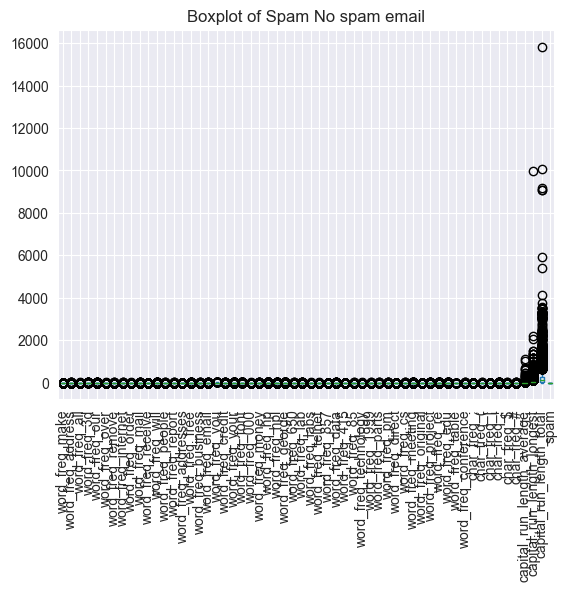

<Axes: xlabel='capital_run_length_longest'>

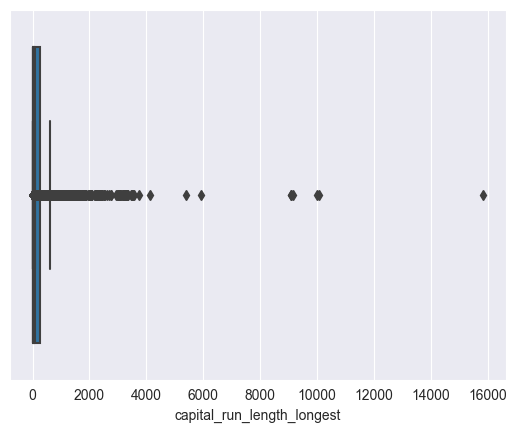

In [5]:
fig = plt.figure(figsize =(100, 50))
dataset_2.plot.box(title='Boxplot of Spam No spam email', rot=90)
plt.show()
sn.boxplot(x = dataset_2['capital_run_length_total'])
sn.boxplot(x = dataset_2['capital_run_length_average'])
sn.boxplot(x = dataset_2['capital_run_length_longest'])

# Assigning NaN to outliers

In [6]:
for input_var in ['capital_run_length_total', 'capital_run_length_longest', 'capital_run_length_average']:
    q75, q25 = np.percentile(dataset_2.loc[:, input_var], [75, 25])
    inter_quartile_range = q75 - q25
    max_value = q75 + (1.5 * inter_quartile_range)
    min_value = q25 - (1.5 * inter_quartile_range)
    dataset_2.loc[dataset_2[input_var] < min_value, input_var] = np.nan
    dataset_2.loc[dataset_2[input_var] > max_value, input_var] = np.nan
dataset_2
dataset_2.isna().sum().any()
dataset_2.isna().sum()

word_freq_make                  0
word_freq_address               0
word_freq_all                   0
word_freq_3d                    0
word_freq_our                   0
word_freq_over                  0
word_freq_remove                0
word_freq_internet              0
word_freq_order                 0
word_freq_mail                  0
word_freq_receive               0
word_freq_will                  0
word_freq_people                0
word_freq_report                0
word_freq_addresses             0
word_freq_free                  0
word_freq_business              0
word_freq_email                 0
word_freq_you                   0
word_freq_credit                0
word_freq_your                  0
word_freq_font                  0
word_freq_000                   0
word_freq_money                 0
word_freq_hp                    0
word_freq_hpl                   0
word_freq_george                0
word_freq_650                   0
word_freq_lab                   0
word_freq_labs

# Removing null values

In [7]:
dataset_3=dataset_2.dropna()
dataset_3=dataset_2.dropna(axis=0)

# Resetting index after removing

<Figure size 10000x5000 with 0 Axes>

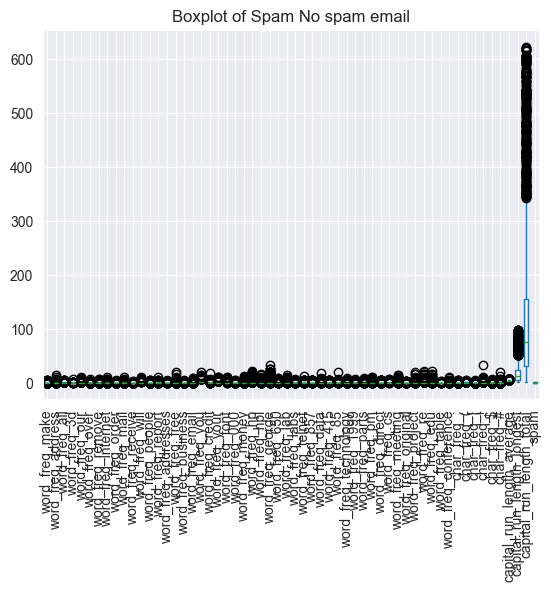

<Axes: xlabel='capital_run_length_longest'>

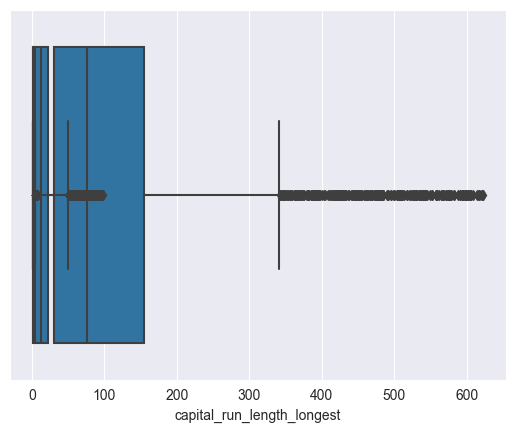

In [8]:
dataset_3=dataset_2.dropna().reset_index(drop=True)
dataset_2 = dataset_3
dataset_3
fig = plt.figure(figsize =(100, 50))
dataset_3.plot.box(title='Boxplot of Spam No spam email', rot=90)
plt.show()
sn.boxplot(x = dataset_2['capital_run_length_total'])
sn.boxplot(x = dataset_2['capital_run_length_average'])
sn.boxplot(x = dataset_2['capital_run_length_longest'])

# Target Var definition

In [9]:
target_var = dataset_3.iloc[:, 57].values
target_var

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

# Input Var definition

In [10]:
input_var = dataset_3.loc[:, dataset_3.columns != 'spam']
input_var
input_var.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,...,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000,3446.000000
mean,0.094779,0.092716,0.268056,0.005818,0.308175,0.085267,0.093688,0.096164,0.047841,0.201033,...,0.038328,0.033385,0.147309,0.017294,0.233433,0.051662,0.033626,2.362797,18.532792,120.788160
std,0.309801,0.474629,0.529981,0.134848,0.701947,0.281174,0.356036,0.420321,0.222685,0.581086,...,0.326526,0.214935,0.244150,0.112672,0.793952,0.194241,0.459684,1.162791,18.751231,130.389669
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.508500,5.000000,31.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.066000,0.000000,0.000000,0.000000,0.000000,2.054000,12.000000,76.000000
75%,0.000000,0.000000,0.360000,0.000000,0.360000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.204000,0.000000,0.237000,0.000000,0.000000,2.909000,23.000000,155.000000
max,4.540000,14.280000,5.100000,7.070000,10.000000,5.880000,7.270000,11.110000,5.260000,11.110000,...,10.000000,4.385000,5.277000,4.081000,32.478000,6.003000,19.829000,6.822000,98.000000,623.000000


# Standardize the features by eliminating the mean and scaling to the measure of variance.

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(input_var)
dataset_4=pd.DataFrame(data=scaled_data, columns= input_var.columns)
dataset_4
dataset_4.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,...,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03,3.446000e+03
mean,-3.299096e-17,-2.474322e-17,7.422965e-17,4.123870e-18,4.948644e-17,-4.948644e-17,-3.299096e-17,2.474322e-17,-2.474322e-17,4.123870e-18,...,-2.474322e-17,-2.061935e-17,6.598191e-17,-4.123870e-18,-2.474322e-17,-8.247739e-17,4.123870e-18,6.598191e-17,-3.299096e-17,1.649548e-17
std,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,...,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00,1.000145e+00
min,-3.059813e-01,-1.953730e-01,-5.058574e-01,-4.315372e-02,-4.390922e-01,-3.032971e-01,-2.631810e-01,-2.288195e-01,-2.148683e-01,-3.460115e-01,...,-1.173999e-01,-1.553462e-01,-6.034406e-01,-1.535136e-01,-2.940565e-01,-2.660056e-01,-7.316004e-02,-1.172176e+00,-9.351566e-01,-9.188270e-01
25%,-3.059813e-01,-1.953730e-01,-5.058574e-01,-4.315372e-02,-4.390922e-01,-3.032971e-01,-2.631810e-01,-2.288195e-01,-2.148683e-01,-3.460115e-01,...,-1.173999e-01,-1.553462e-01,-6.034406e-01,-1.535136e-01,-2.940565e-01,-2.660056e-01,-7.316004e-02,-7.348022e-01,-7.218063e-01,-6.887140e-01
50%,-3.059813e-01,-1.953730e-01,-5.058574e-01,-4.315372e-02,-4.390922e-01,-3.032971e-01,-2.631810e-01,-2.288195e-01,-2.148683e-01,-3.460115e-01,...,-1.173999e-01,-1.553462e-01,-3.330760e-01,-1.535136e-01,-2.940565e-01,-2.660056e-01,-7.316004e-02,-2.656043e-01,-3.484433e-01,-3.435446e-01
75%,-3.059813e-01,-1.953730e-01,1.735113e-01,-4.315372e-02,7.384151e-02,-3.032971e-01,-2.631810e-01,-2.288195e-01,-2.148683e-01,-3.460115e-01,...,-1.173999e-01,-1.553462e-01,2.322319e-01,-1.535136e-01,4.493408e-03,-2.660056e-01,-7.316004e-02,4.698022e-01,2.382701e-01,2.624196e-01
max,1.435073e+01,2.989567e+01,9.118532e+00,5.239393e+01,1.380907e+01,2.061203e+01,2.015906e+01,2.620720e+01,2.340938e+01,1.877615e+01,...,3.051252e+01,2.024913e+01,2.101344e+01,3.607177e+01,4.061861e+01,3.064342e+01,4.306921e+01,3.835470e+00,4.238588e+00,3.852182e+00


# PCA | Principal Component Analysis

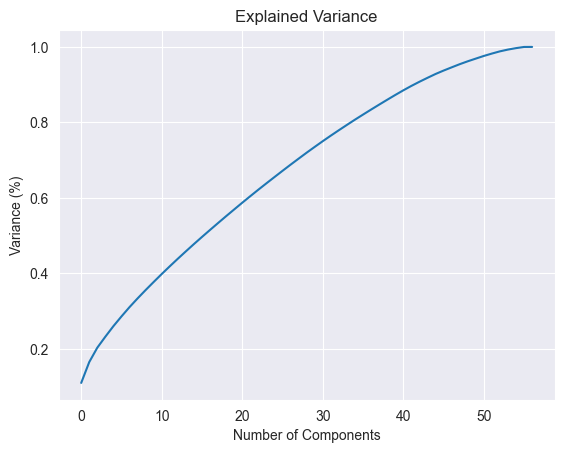

In [12]:
from sklearn.decomposition import PCA
pca = PCA()
transformed_data = pca.fit_transform(dataset_4)
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)')
plt.title('Explained Variance')
plt.show()

# After removing components with higher variance, now 45 are remaining

In [13]:
pca = PCA(n_components=45)
new_component = pca.fit_transform(dataset_4)

dataset_5 = pd.DataFrame(data = new_component)
dataset_5

,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
0,-1.006857,1.802151,0.718619,0.075069,-0.217664,-0.058830,-1.193092,-0.852682,1.060269,0.868241,...,0.225211,0.054747,0.541801,-0.015372,0.165495,-0.109306,0.044770,-0.536423,-0.316815,-0.518088
1,-0.985097,1.538500,0.306286,-0.027354,-0.287019,-0.185419,-0.690249,0.207739,-0.356697,-0.197853,...,-0.600609,0.333896,0.341901,-0.794615,0.293032,-0.134569,0.074910,0.328245,-0.537601,-0.597109
2,-0.986344,1.538184,0.305696,-0.026643,-0.287297,-0.184847,-0.690862,0.206869,-0.356970,-0.199400,...,-0.599516,0.331404,0.344820,-0.795799,0.294337,-0.132262,0.074365,0.327613,-0.537194,-0.596432
3,-0.589457,-0.147096,-0.010590,0.294656,-0.673055,-0.410960,0.165474,0.738062,-1.293897,-0.064280,...,-1.154249,1.043284,0.808141,-0.762942,1.201945,0.436507,-0.706787,0.287732,-0.548211,-0.850396
4,-1.147369,0.762939,-1.665278,0.687323,-0.063357,1.574638,-1.343952,-0.180081,-0.197004,-0.557199,...,-0.336657,1.359865,-0.600721,0.105871,0.534949,0.399881,1.110311,-0.397773,0.415492,-0.008937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,-0.541647,-1.320158,-0.551831,0.452446,-0.288104,-0.497818,0.169153,0.147472,0.376760,-0.867539,...,0.472522,0.451911,-0.338784,-0.312221,-0.304151,0.255506,-0.393099,0.156998,0.328377,0.069296
3442,-0.934433,-0.987027,-1.271991,-0.126766,1.537215,-0.243438,-0.066440,0.812400,0.844384,-0.507252,...,0.439630,-0.279639,0.526322,1.114122,0.492807,-0.993248,0.111043,0.164559,-0.053381,-0.447345
3443,-0.279227,-0.860494,-0.162327,0.119453,0.155817,-0.202262,0.133899,-0.148548,1.331307,-0.828559,...,0.496912,1.001115,-1.004783,0.378800,-0.561870,-0.698446,-0.593443,0.173638,-0.023781,-0.650488
3444,-0.713477,-1.124775,-0.833385,0.310052,0.308561,-0.316090,-0.124831,0.220862,0.415830,-0.398617,...,-0.206080,0.036830,0.915643,-0.093382,0.186083,-0.435946,-0.195009,-0.241905,-0.131292,0.009480


# KNN | K Nearest Neighbor

# Splitting data

In [14]:
from sklearn.model_selection import train_test_split
train_k_features,test_k_features,train_k_target,test_k_target = train_test_split(dataset_5, target_var, test_size = 0.25, random_state = 0)

# Training the classifier
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(train_k_features, train_k_target)

KNeighborsClassifier()

# Test data accuracy

In [15]:
classifier.score(test_k_features, test_k_target)

0.8932714617169374

# Result prediction of test dataset

In [16]:
feature_prediction = classifier.predict(test_k_features)

# Train data accuracy

In [17]:
from sklearn.metrics import accuracy_score
predictions_train_KNN = classifier.predict(train_k_features)
accuracy_score(train_k_target, predictions_train_KNN)

0.9291795665634675

# Confusion Matrix for KNN

Text(58.222222222222214, 0.5, 'Truth')

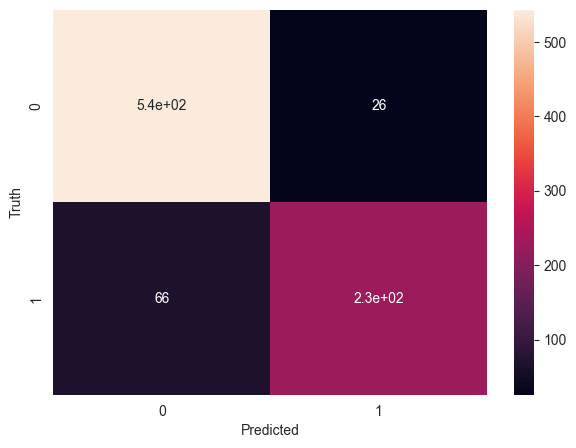

In [18]:
from sklearn.metrics import confusion_matrix
confusion_mat1 = confusion_matrix(test_k_target, feature_prediction)
confusion_mat1
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
sn.heatmap(confusion_mat1, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Classification Report for KNN

In [19]:
from sklearn.metrics import classification_report
KNN_analysis = classification_report(test_k_target, feature_prediction)
print(KNN_analysis)

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       569
           1       0.90      0.77      0.83       293

    accuracy                           0.89       862
   macro avg       0.89      0.86      0.88       862
weighted avg       0.89      0.89      0.89       862



# DT | Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Train test split
train_dt_features,test_dt_features,train_dt_targets,test_dt_targets = train_test_split(dataset_5, target_var, test_size=0.25, random_state=3)

# Defining Decision Tree Classifier
# I reduced the maximum depth parameter's value to prevent overfitting.
Decision_Tree_classifier = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
Decision_Tree_classifier

DecisionTreeClassifier(criterion='entropy', max_depth=4)

# Training Decision Tree Classifier

In [21]:
Decision_Tree_classifier.fit(train_dt_features, train_dt_targets)
from sklearn.metrics import accuracy_score

# Test data accuracy

In [22]:
DT_test_predict = Decision_Tree_classifier.predict(test_dt_features)
accuracy_score(test_dt_targets, DT_test_predict)

0.8990719257540604

# Train data accuracy

In [23]:
DT_train_predict = Decision_Tree_classifier.predict(train_dt_features)
accuracy_score(train_dt_targets, DT_train_predict)
DT_predict = Decision_Tree_classifier.predict(test_dt_features)

In [24]:
from sklearn import metrics
import matplotlib.pyplot as plt
print("Accuracy of the above trained decition tree is : ", metrics.accuracy_score(test_dt_targets, DT_predict))
predicted_dt_targets = Decision_Tree_classifier.predict(test_dt_features)

Accuracy of the above trained decition tree is :  0.8990719257540604


# Confusion Matrix for Decision tree

Text(58.222222222222214, 0.5, 'Truth')

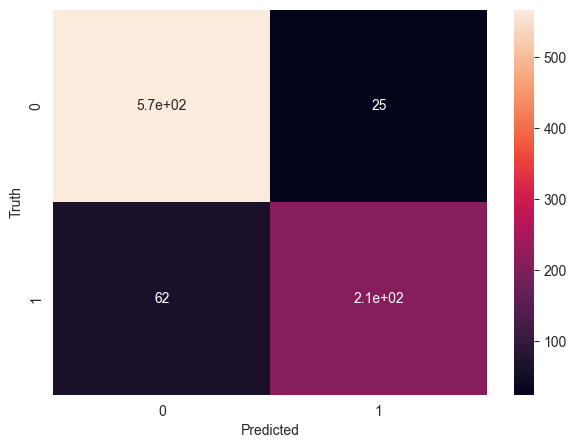

In [25]:
from sklearn.metrics import confusion_matrix
confusion_mat2 = confusion_matrix(test_dt_targets, predicted_dt_targets)
confusion_mat2
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(confusion_mat2, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Classification report for Decision tree

In [26]:
DT_analysis = classification_report(test_dt_targets, predicted_dt_targets)
print(DT_analysis)

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       592
           1       0.89      0.77      0.83       270

    accuracy                           0.90       862
   macro avg       0.90      0.86      0.88       862
weighted avg       0.90      0.90      0.90       862



# Visualization of Decision Tree

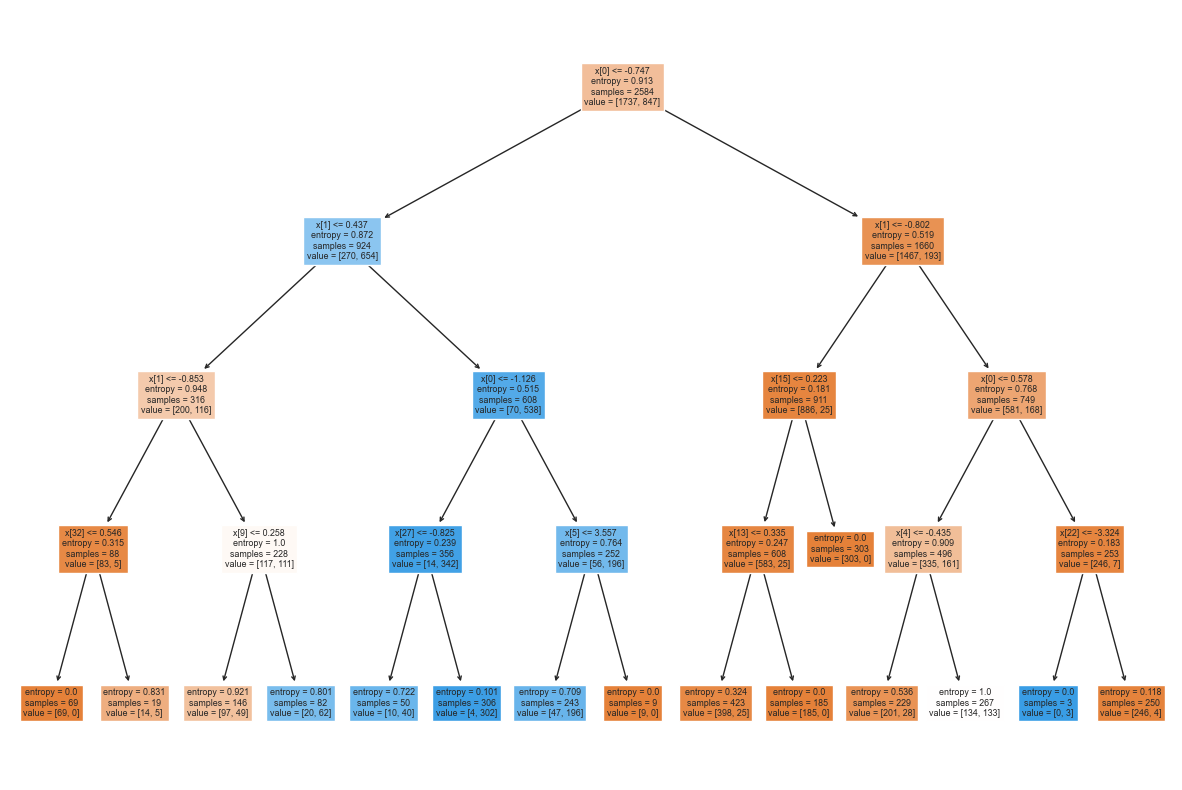

In [27]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(Decision_Tree_classifier, filled=True)
plt.show()
from sklearn.metrics import roc_curve,auc
from sklearn.metrics import roc_auc_score
DT_probabilities = Decision_Tree_classifier.predict_proba(test_dt_features)[:, 1]
DT_probabilities
fpr_dt, tpr_dt, thresholds_dt = roc_curve(test_dt_targets, DT_probabilities)

# Plotting ROC curve

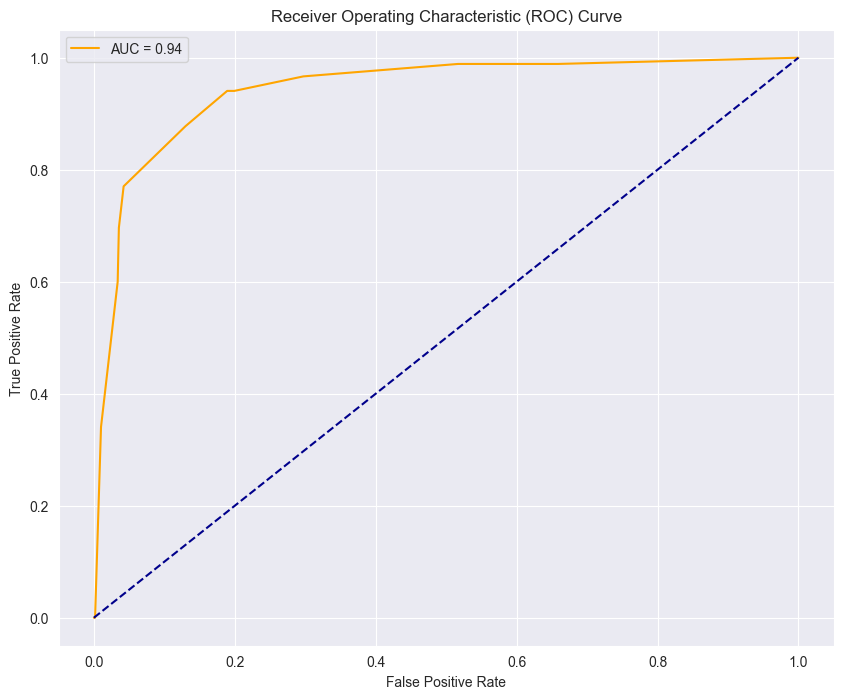

In [28]:
auc_score = auc(fpr_dt, tpr_dt)
auc_score
def plot_roc_curve(fpr, tpr):
    plt.figure(figsize=(10,8))
    plt.plot(fpr_dt, tpr_dt, color='orange', label='AUC = %0.2f' % auc_score)
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
plot_roc_curve(fpr_dt,tpr_dt)